# Image Quality Toolset - Getting Started

This notebook walks you through the **Image Quality Toolset**, a set of algorithms for computing:

- **MTF** (Modulation Transfer Function) — measures how well an imaging system reproduces spatial detail
- **SNR** (Signal-to-Noise Ratio) — measures the ratio of useful signal to background noise

Two methods are available:

| Method | Name | Description |
|--------|------|-------------|
| MTF | MTF Estimator | MTF computation method with parametric/non-parametric ESF models |
| SNR | SNR Estimator | Signal-to-Noise Ratio estimator |

Four test datasets are included:

| Dataset | Sensor | Config file | ROI type |
|---------|--------|-------------|----------|
| `target1/` | Sentinel-2 (Bagnolo) | `bagnolo_MTF.ini` | Shapefile |
| `target2/` | PAN target | `pan_target_MTF.ini` | Crop window |
| `target3/` | Pléiades Neo | `pneo_MTF.ini` | Shapefile |
| `target4/` | Landsat-9 (desert) | `desert_SNR.ini` | Shapefile |

---
## 1. Environment Setup

Before running this notebook, make sure you have:

1. Created the conda environment:
   ```bash
   conda env create -f image_quality_toolset/environment.yml
   conda activate mtf
   ```

2. Set the required environment variable:
   ```bash
   conda env config vars set IMAGE_QUALITY_TOOL_HOME=/absolute/path/to/image_quality_tool
   conda deactivate && conda activate mtf
   ```

3. Set the PYTHONPATH:
   ```bash
   conda env config vars set PYTHONPATH=$IMAGE_QUALITY_TOOL_HOME
   conda deactivate && conda activate mtf
   ```

The cell below verifies that your environment is correctly configured.

In [14]:
import os
import sys

# Check IMAGE_QUALITY_TOOL_HOME
iqt_home = os.environ.get("IMAGE_QUALITY_TOOL_HOME")
if iqt_home is None:
    raise EnvironmentError(
        "IMAGE_QUALITY_TOOL_HOME is not set.\n"
        "Run: conda env config vars set IMAGE_QUALITY_TOOL_HOME=/path/to/image_quality_toolset"
    )

# Ensure it is on PYTHONPATH so imports work
if iqt_home not in sys.path:
    sys.path.insert(0, iqt_home)

print(f"IMAGE_QUALITY_TOOL_HOME = {iqt_home}")
print(f"Python version: {sys.version}")

# Verify key dependencies
import numpy as np
import matplotlib
import scipy
from osgeo import gdal
from qgis.core import QgsApplication

print(f"numpy      {np.__version__}")
print(f"matplotlib {matplotlib.__version__}")
print(f"scipy      {scipy.__version__}")
print(f"GDAL       {gdal.__version__}")
print("\nAll dependencies OK.")

IMAGE_QUALITY_TOOL_HOME = /home/romain/work/image-quality-tool
Python version: 3.9.18 | packaged by conda-forge | (main, Dec 23 2023, 16:33:10) 
[GCC 12.3.0]
numpy      2.0.2
matplotlib 3.9.4
scipy      1.13.1
GDAL       3.10.2

All dependencies OK.


In [15]:
# Common imports used throughout this notebook
import threading
import time
import matplotlib.pyplot as plt
%matplotlib inline

import ipywidgets as widgets
from IPython.display import display

from scripts.mtf_computer import process_algorithm, load_config, crop_image


def run_with_progress(config_file, description="Processing"):
    """Run process_algorithm with an animated progress bar and debug info."""
    config = load_config(config_file)
    if config.get('debug') and config.get('debug_dir'):
        debug_rel = os.path.relpath(config['debug_dir'])
        print(f"Debug images are being generated under: {debug_rel}")

    progress = widgets.FloatProgress(
        value=0, min=0, max=100,
        description=description,
        bar_style='info',
        layout=widgets.Layout(width='50%'),
    )
    display(progress)

    result = [None]
    error = [None]

    def _run():
        try:
            result[0] = process_algorithm(config_file)
        except Exception as e:
            error[0] = e

    t = threading.Thread(target=_run)
    t.start()

    step = 0
    while t.is_alive():
        step = min(step + 2, 90)
        progress.value = step
        time.sleep(0.3)

    progress.value = 100
    progress.bar_style = 'success'
    progress.description = 'Done!'

    if error[0]:
        raise error[0]

    return result[0]

---
## 2. Discover the Test Data

The toolset ships with four datasets so you can experiment right away.

Bagnolo shape : (1000, 1000)
Value range   : [1113.0, 19120.0]


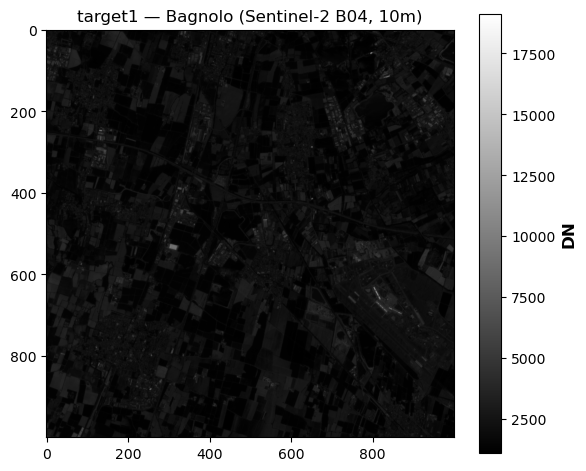

In [16]:
# ----- Dataset 1 (target1): Bagnolo - Sentinel-2 raster with shapefile ROI -----
bagnolo_path = os.path.join(iqt_home, "test", "data", "target1",
                            "T32TNR_20250619T101559_B04_10m_mtf_roi.tiff")

ds = gdal.Open(bagnolo_path, gdal.GA_ReadOnly)
bagnolo_array = ds.GetRasterBand(1).ReadAsArray().astype(np.float64)
ds = None

print(f"Bagnolo shape : {bagnolo_array.shape}")
print(f"Value range   : [{bagnolo_array.min():.1f}, {bagnolo_array.max():.1f}]")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(bagnolo_array, cmap="gray")
ax.set_title("target1 — Bagnolo (Sentinel-2 B04, 10m)")
plt.colorbar(im, ax=ax, label="DN")
plt.tight_layout()
plt.show()

PAN target shape : (80, 80)
Value range      : [2655.0, 12795.0]


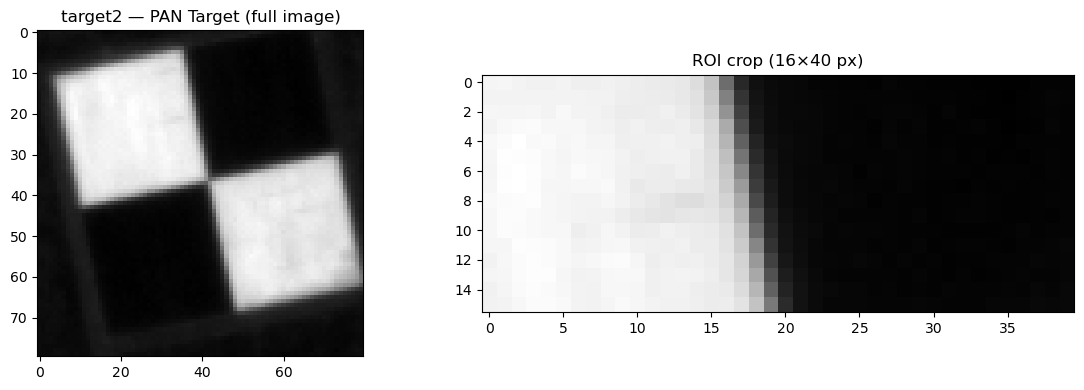

In [17]:
# ----- Dataset 2 (target2): PAN target - small edge image with crop window ROI -----
pan_path = os.path.join(iqt_home, "test", "data", "target2",
                        "S100199aI_002_2_PAN_L0R_mtf_target.tif")

ds = gdal.Open(pan_path, gdal.GA_ReadOnly)
pan_array = ds.GetRasterBand(1).ReadAsArray().astype(np.float64)
ds = None

print(f"PAN target shape : {pan_array.shape}")
print(f"Value range      : [{pan_array.min():.1f}, {pan_array.max():.1f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(pan_array, cmap="gray")
axes[0].set_title("target2 — PAN Target (full image)")

# Show the ROI crop used in pan_target_MTF.ini
roi = {"line": 13, "pixel": 21, "line_number": 16, "pixel_number": 40}
crop = pan_array[roi["line"]:roi["line"]+roi["line_number"],
                 roi["pixel"]:roi["pixel"]+roi["pixel_number"]]
axes[1].imshow(crop, cmap="gray")
axes[1].set_title(f"ROI crop ({crop.shape[0]}×{crop.shape[1]} px)")

plt.tight_layout()
plt.show()

Pléiades Neo bands : 3
Raster size        : 4427 × 4342 px
Band 1 value range : [1.0, 31944.0]


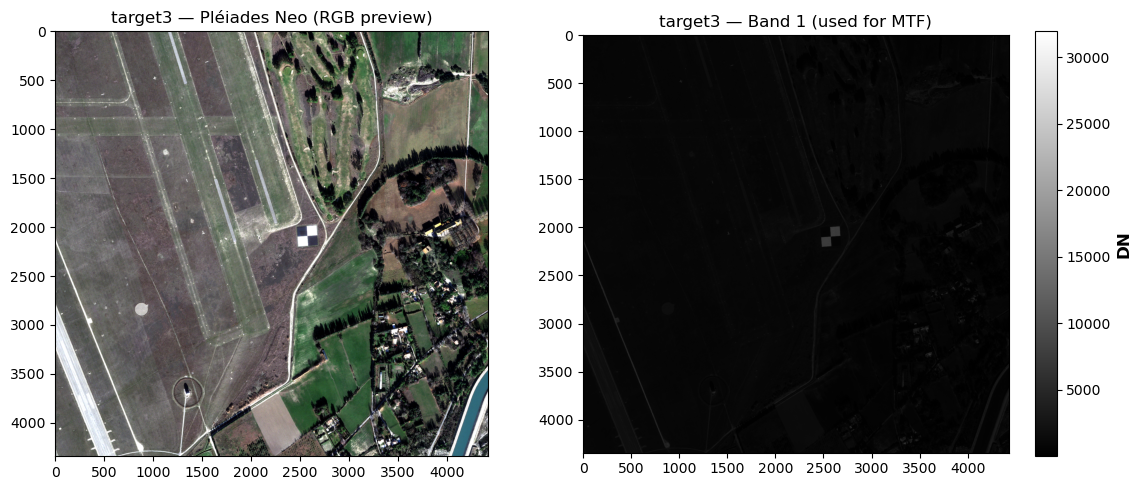

In [18]:
# ----- Dataset 3 (target3): Pléiades Neo - RGB MTF target with shapefile ROI -----
pneo_path = os.path.join(iqt_home, "test", "data", "target3",
                         "IMG_PNEO4_202312251040354_PMS-N_SEN_PWOI_000184796_RGB_MTF_TARGET.tif")

ds = gdal.Open(pneo_path, gdal.GA_ReadOnly)
n_bands = ds.RasterCount
print(f"Pléiades Neo bands : {n_bands}")
print(f"Raster size        : {ds.RasterXSize} × {ds.RasterYSize} px")

# Read R, G, B bands (bands 1, 2, 3) and build an 8-bit RGB preview
def band_to_uint8(band_array):
    p2, p98 = np.percentile(band_array, (2, 98))
    clipped = np.clip(band_array, p2, p98)
    return ((clipped - p2) / (p98 - p2) * 255).astype(np.uint8)

rgb = np.stack([
    band_to_uint8(ds.GetRasterBand(b).ReadAsArray().astype(np.float64))
    for b in (1, 2, 3)
], axis=-1)
band1 = ds.GetRasterBand(1).ReadAsArray().astype(np.float64)
ds = None

print(f"Band 1 value range : [{band1.min():.1f}, {band1.max():.1f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(rgb)
axes[0].set_title("target3 — Pléiades Neo (RGB preview)")

im = axes[1].imshow(band1, cmap="gray")
axes[1].set_title("target3 — Band 1 (used for MTF)")
plt.colorbar(im, ax=axes[1], label="DN")

plt.tight_layout()
plt.show()

Landsat-9 desert shape : (1000, 1000)
Value range            : [66.53, 182.11]


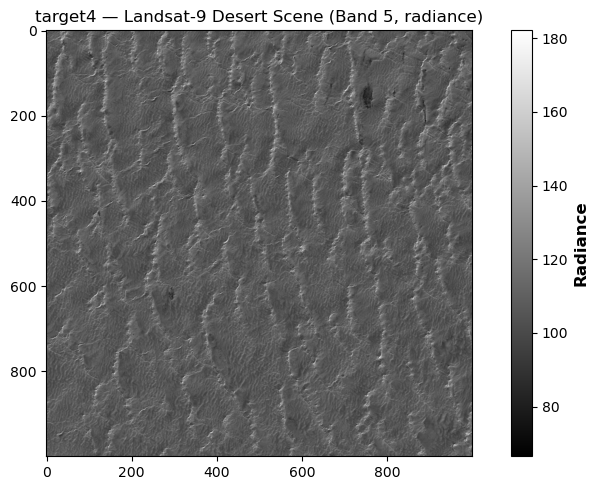

In [19]:
# ----- Dataset 4 (target4): Landsat-9 desert - single-band radiance image with shapefile ROI -----
desert_path = os.path.join(iqt_home, "test", "data", "target4",
                           "LC09_L1TP_181040_20211121_20230505_02_T1_B5_rad_crop_2.tif")

ds = gdal.Open(desert_path, gdal.GA_ReadOnly)
desert_array = ds.GetRasterBand(1).ReadAsArray().astype(np.float64)
ds = None

print(f"Landsat-9 desert shape : {desert_array.shape}")
print(f"Value range            : [{desert_array.min():.2f}, {desert_array.max():.2f}]")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(desert_array, cmap="gray")
ax.set_title("target4 — Landsat-9 Desert Scene (Band 5, radiance)")
plt.colorbar(im, ax=ax, label="Radiance")
plt.tight_layout()
plt.show()

---
## 3. MTF on PAN Target (Crop Window ROI)

We use `pan_target_MTF.ini`, which defines the ROI as a pixel crop window directly in the config — no shapefile needed.

The MTF method implements the following pipeline:
1. Image oversampling & rotation
2. Non-equally-spaced ESF extraction
3. Parametric or non-parametric ESF model fitting
4. Sgolay filtering → LSF → FFT → MTF curve

### Key parameters

| Parameter | Description | Values |
|-----------|-------------|--------|
| `radiometric_scale` | Radiance conversion factor | float |
| `radiometric_offset` | Offset correction | float |
| `px_margin` | Pixel margin for edge extraction | int |
| `edge_direction` | Edge orientation | `AL` (Along-Track) / `CT` (Cross-Track) |
| `method_type` | ESF interpolation | `PARAM` or `NON_PARAM` |
| `esf_model` | Parametric model | `sigmoid`, `esf_tanh`, `esf_fermi`, `esf_gauss_exp_param` |

In [20]:
# Run MTF on the PAN target (crop window ROI)
config_pan_mtf = os.path.join(iqt_home, "test", "data", "config_files", "pan_target_MTF.ini")

print("=== Configuration ===")
with open(config_pan_mtf) as f:
    print(f.read())

=== Configuration ===
[input]
image_path = $IMAGE_QUALITY_TOOL_HOME/test/data/target2/S100199aI_002_2_PAN_L0R_mtf_target.tif
ROI = {'line': 13, 'pixel': 21, 'line_number': 16, 'pixel_number': 40}

[parameters]
# MANDATORY PARAMETERS
method = MTF
band = 1

# METHOD 2 PARAMETERS
scale = 0.01
offset = 1.0
px_margin = 12
edge_direction = AL
esf_model = sigmoid
sampling = 0.2

[debug]
enabled = true
dir = $IMAGE_QUALITY_TOOL_HOME/output/pan_target_m2




Debug images are being generated under: output/pan_target_m2


FloatProgress(value=0.0, bar_style='info', description='MTF PAN:', layout=Layout(width='50%'))

 -- MTF AC Track         --
Number of processed BINs / Total : 200 / 201   :
Number of Oversample Edge Profile   : 81
 Show AL Edge
Selected window half-length: 18.2 pixels
Number of samples: 200
ESF width in pixels: 40.0
Inflection point at x=91.0, ESF value=80.54666666666667
Inflection point in pixels: 18.0 px
Fitted sigmoid: amplitude=-94.8232, baseline=124.2956, x_center=91.3829, slope=0.2783
- Compute RER on normalize Edge Spread Function
- Compute HEE on normalize Edge Spread Function


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

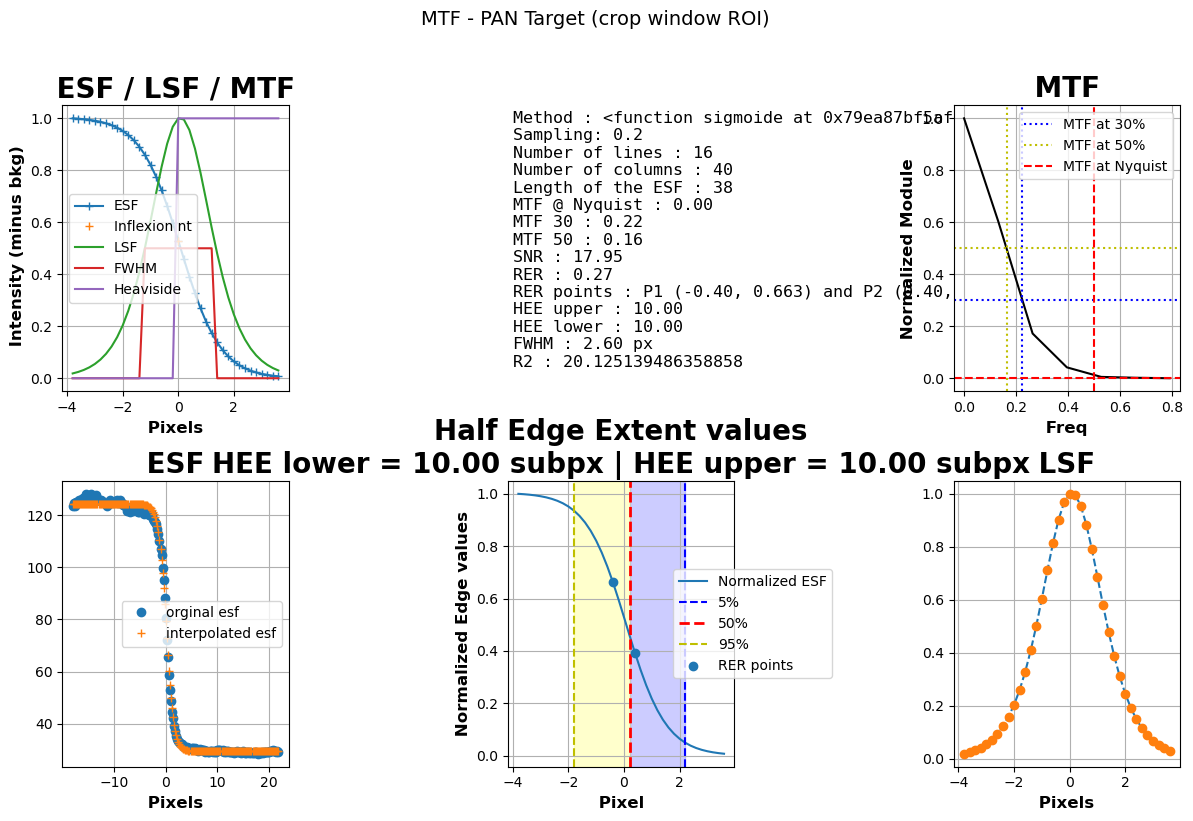

In [21]:
mtf_pan = run_with_progress(config_pan_mtf, description="MTF PAN:")

fig = mtf_pan.figure()
fig.set_size_inches(12, 8)
fig.suptitle("MTF - PAN Target (crop window ROI)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The 4-panel figure shows:
- **Top-left**: Edge image with detected edge line (green) and subpixel positions (red)
- **Top-right**: ESF (red) and LSF (green) estimation with sigmoid fit (black). Dashed lines mark FWHM boundaries.
- **Bottom-left**: MTF modulus vs spatial frequency
- **Bottom-right**: Computed metrics (Angle, Smooth factor, FWHM, MTF30, MTF50, MTF@Nyquist)

---
## 4. MTF on Bagnolo (Shapefile ROI)

We use `bagnolo_MTF.ini`, which references a shapefile to define the ROI. This is the typical workflow for real satellite imagery where the edge target is delineated in a GIS tool.

In [22]:
# Run MTF on the Bagnolo Sentinel-2 dataset (shapefile ROI)
config_bagnolo_mtf = os.path.join(iqt_home, "test", "data", "config_files", "bagnolo_MTF.ini")

print("=== Configuration ===")
with open(config_bagnolo_mtf) as f:
    print(f.read())

=== Configuration ===
[input]
image_path = $IMAGE_QUALITY_TOOL_HOME/test/data/target1/T32TNR_20250619T101559_B04_10m_mtf_roi.tiff
ROI = $IMAGE_QUALITY_TOOL_HOME/test/data/target1/shapefile/mtf_al_bagnolo.shp

[parameters]
# MANDATORY PARAMETERS
method = MTF
band = 1

# METHOD 2 PARAMETERS
scale = 0.01
offset = 1.0
px_margin = 12
edge_direction = AL
esf_model = sigmoid
sampling = 0.2

[debug]
enabled = true
dir = $IMAGE_QUALITY_TOOL_HOME/output/bagnolo_raster_m2



Debug images are being generated under: output/bagnolo_raster_m2


FloatProgress(value=0.0, bar_style='info', description='MTF Bagnolo:', layout=Layout(width='50%'))

Application path not initialized
Application path not initialized
Application path not initialized
Application path not initialized


 -- MTF AC Track         --
Number of processed BINs / Total : 104 / 141   :
Number of Oversample Edge Profile   : 166
 Show AL Edge
Selected window half-length: 9.4 pixels
Number of samples: 104
ESF width in pixels: 25.0
Inflection point at x=78.0, ESF value=23.544
Inflection point in pixels: 11.200000000000001 px
Fitted sigmoid: amplitude=12.9071, baseline=15.6123, x_center=76.2962, slope=0.3136
- Compute RER on normalize Edge Spread Function
- Compute HEE on normalize Edge Spread Function


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

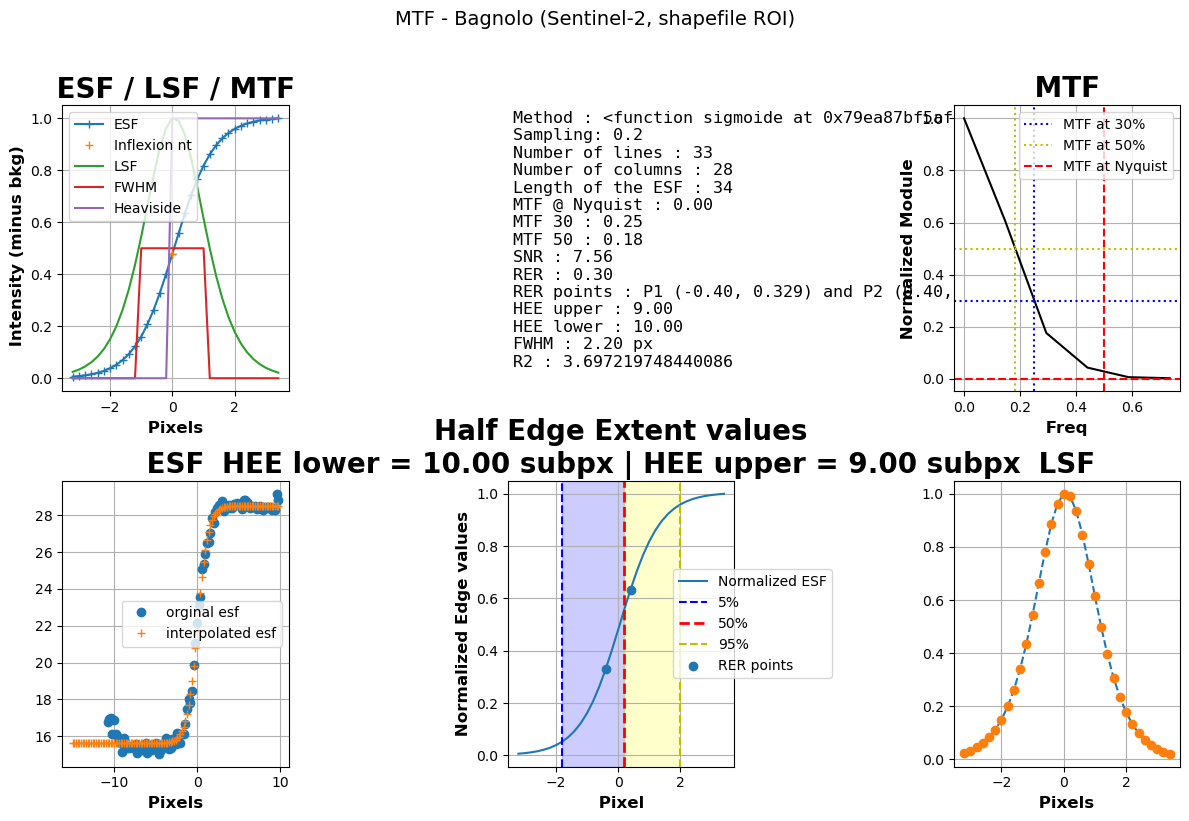


--- MTF Metrics ---
FWHM         : 2.2000 px
RER          : 0.3047
SNR          : 7.56
MTF@Nyquist  : 0.0000
Edge angle   : -13.82 deg


In [23]:
mtf_bagnolo = run_with_progress(config_bagnolo_mtf, description="MTF Bagnolo:")

fig = mtf_bagnolo.figure()
fig.set_size_inches(12, 8)
fig.suptitle("MTF - Bagnolo (Sentinel-2, shapefile ROI)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n--- MTF Metrics ---")
print(f"FWHM         : {mtf_bagnolo.FWHM:.4f} px")
print(f"RER          : {mtf_bagnolo.RER:.4f}")
print(f"SNR          : {mtf_bagnolo.SNR:.2f}")
print(f"MTF@Nyquist  : {mtf_bagnolo.MTF_NYQ:.4f}")
print(f"Edge angle   : {mtf_bagnolo.angle:.2f} deg")

---
## 5. SNR on Desert Scene (Landsat-9)

We use `desert_SNR.ini`. The SNR estimator:
1. Smooths the image with a uniform filter
2. Uses **Sobel edge detection** to identify uniform (flat) regions
3. Computes noise as the difference between the original and smoothed image
4. Calculates SNR using two formulations:
   - **Formulation 1**: mean / sigma_noise (binned per radiance level)
   - **JACIE formulation**: histogram-based peak SNR estimate

=== Configuration ===
[input]
image_path = $IMAGE_QUALITY_TOOL_HOME/test/data/target4/LC09_L1TP_181040_20211121_20230505_02_T1_B5_rad_crop_2.tif
ROI = $IMAGE_QUALITY_TOOL_HOME/test/data/target4/shapefile/ROI.shp

[parameters]
# MANDATORY PARAMETERS
method = SNR
band = 1

# SNR METHOD SPECIFIC PARAMETERS
window_size = 5
snr_precision = 0.1
L_min = 100
L_max = 160

[debug]
enabled = true
dir = $IMAGE_QUALITY_TOOL_HOME/output/desert_m3

Debug images are being generated under: output/desert_m3


FloatProgress(value=0.0, bar_style='info', description='SNR Desert:', layout=Layout(width='50%'))

Application path not initialized
Application path not initialized
Application path not initialized
Application path not initialized


 Band Number in the processing              : 1.00
 Scale                                      : 1.000000
 Offset                                     : 0.000000
 Input SNR precision                      : 0.1
 Width of the histogram bin is 2*c        : 0.2
Image: 959×944 = 905,296 pixels
Sampled: 4,376 points (stratified: 22×22 strata)
Ratio: 0.48%

Computing variogram...
 - Model: spherical, Estimator: dowd
SNR Computed from variogram:  23.201013688137852
Parameters fitted: (np.float64(1248.4405073857074), np.float64(18.20007957657274), np.float64(10.267608162760466))
Nugget Computed from variogram:  43.99393373518204
 Minimum / Maximum Radiance of selected pixels in input: 66.53 / 182.11
 Percentage of selected pixels: 89.84 %
 Minimum / Maximum Radiance of filtered images: 100.01 / 159.98
 Statistics per bin of 1 W
 Histogram BIN Number        : 60.00
 Quadratic Error (med / mean) : 0.09
JACIE SNR Value        : 25.20 @ 108.67
Quantitative SNR Value : 30.18 @ 129.99
SNR Value (Formu

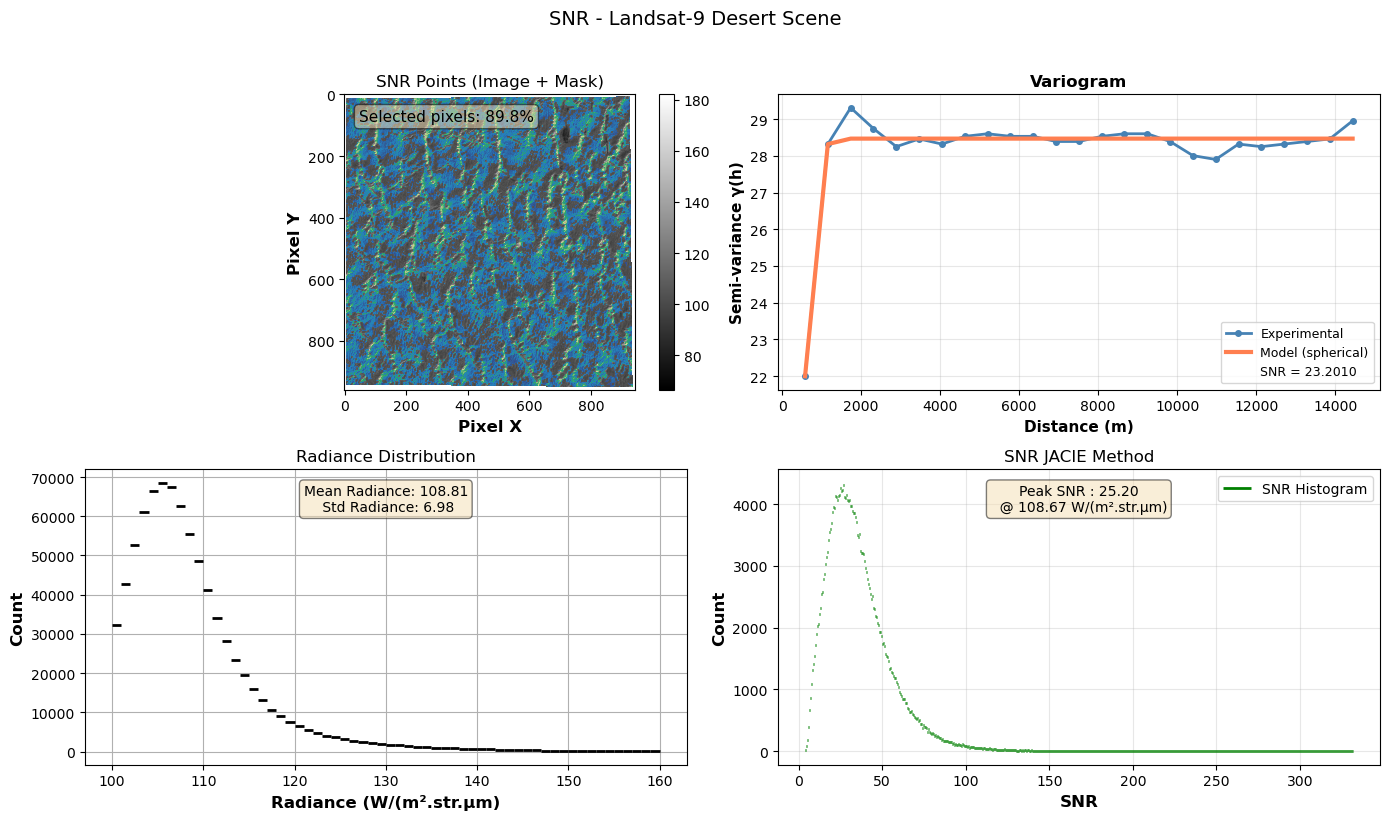

In [24]:
# Run SNR on the Landsat-9 desert dataset (shapefile ROI)
config_desert_snr = os.path.join(iqt_home, "test", "data", "config_files", "desert_SNR.ini")

print("=== Configuration ===")
with open(config_desert_snr) as f:
    print(f.read())

snr_desert = run_with_progress(config_desert_snr, description="SNR Desert:")

fig = snr_desert.figure()
fig.set_size_inches(14, 8)
fig.suptitle("SNR - Landsat-9 Desert Scene", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. MTF on Pléiades Neo (target3)

We use `pneo_MTF.ini` to run MTF on the Pléiades Neo MTF target scene with a shapefile ROI.

=== Configuration ===
[input]
image_path = $IMAGE_QUALITY_TOOL_HOME/test/data/target3/IMG_PNEO4_202312251040354_PMS-N_SEN_PWOI_000184796_RGB_MTF_TARGET.tif
ROI = $IMAGE_QUALITY_TOOL_HOME/test/data/target3/shapefile/roi_mtf2.shp

[parameters]
# MANDATORY PARAMETERS
method = MTF
band = 1

# METHOD 2 PARAMETERS
scale = 0.01
offset = 1.0
px_margin = 12
edge_direction = AL
esf_model = sigmoid
sampling = 0.2


[debug]
enabled = true
dir = $IMAGE_QUALITY_TOOL_HOME/output/pneo_m2

Debug images are being generated under: output/pneo_m2


FloatProgress(value=0.0, bar_style='info', description='MTF Pléiades Neo:', layout=Layout(width='50%'))

Application path not initialized
Application path not initialized
Application path not initialized
Application path not initialized


 -- MTF AC Track         --
Number of processed BINs / Total : 447 / 461   :
Number of Oversample Edge Profile   : 396
 Show AL Edge
Selected window half-length: 45.2 pixels
Number of samples: 447
ESF width in pixels: 92.0
Inflection point at x=234.0, ESF value=44.998666666666665
Inflection point in pixels: 44.0 px
Fitted sigmoid: amplitude=70.0280, baseline=7.0094, x_center=233.3896, slope=0.5160
- Compute RER on normalize Edge Spread Function
- Compute HEE on normalize Edge Spread Function


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

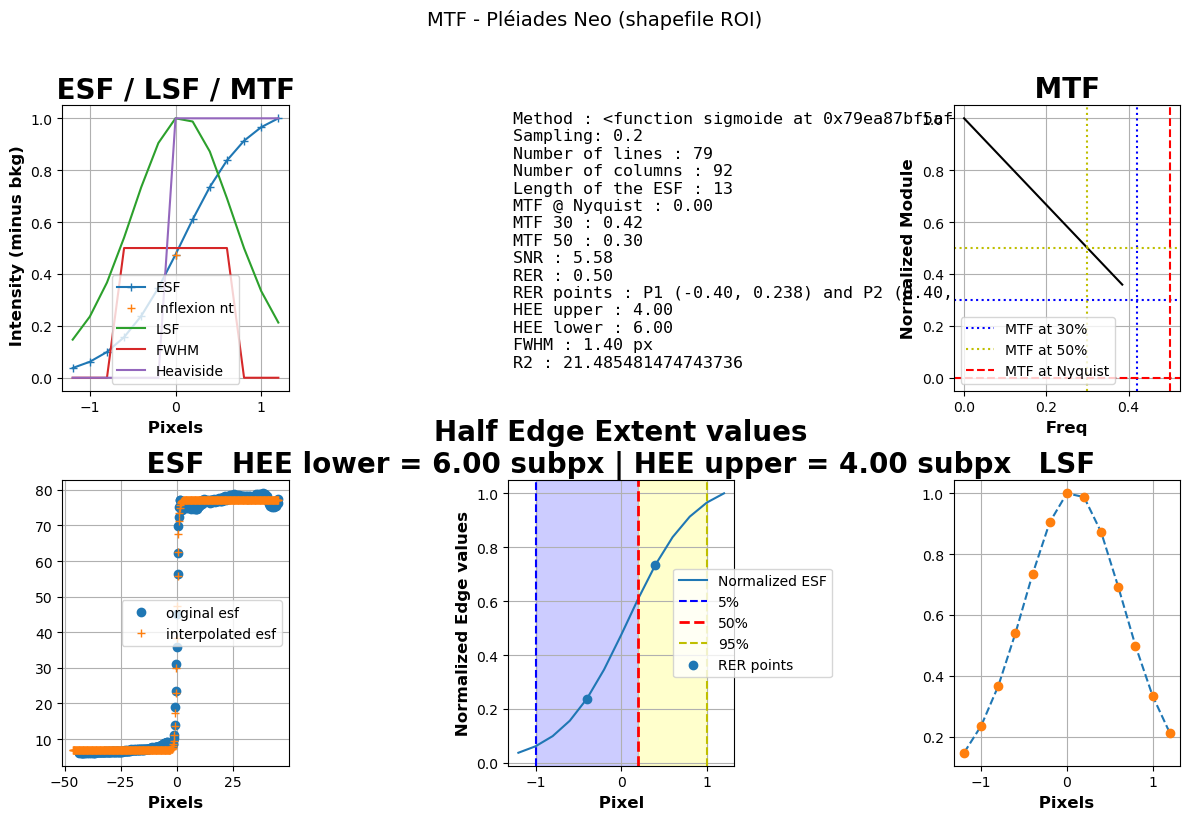


--- MTF Metrics ---
FWHM         : 1.4000 px
RER          : 0.4969
SNR          : 5.58
MTF@Nyquist  : 0.0000
Edge angle   : 3.89 deg


In [25]:
# Run MTF on the Pléiades Neo target (shapefile ROI)
config_pneo_mtf = os.path.join(iqt_home, "test", "data", "config_files", "pneo_MTF.ini")

print("=== Configuration ===")
with open(config_pneo_mtf) as f:
    print(f.read())

mtf_pneo = run_with_progress(config_pneo_mtf, description="MTF Pléiades Neo:")

fig = mtf_pneo.figure()
fig.set_size_inches(12, 8)
fig.suptitle("MTF - Pléiades Neo (shapefile ROI)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n--- MTF Metrics ---")
print(f"FWHM         : {mtf_pneo.FWHM:.4f} px")
print(f"RER          : {mtf_pneo.RER:.4f}")
print(f"SNR          : {mtf_pneo.SNR:.2f}")
print(f"MTF@Nyquist  : {mtf_pneo.MTF_NYQ:.4f}")
print(f"Edge angle   : {mtf_pneo.angle:.2f} deg")

---
## 7. Bring Your Own Image

To analyze your own images:

1. **Create an INI configuration file** following the template below
2. Call `process_algorithm()` with the path to your config file

### ROI definition

There are two ways to define the Region of Interest (ROI):

- **Crop window** (pixel coordinates): `ROI = {'line': 0, 'pixel': 0, 'line_number': 100, 'pixel_number': 200}`
- **Shapefile**: `ROI = /path/to/my_roi.shp`

### Config file template

In [26]:
# Template: copy and adapt this to create your own config file
config_template = """
[input]
image_path = /path/to/your/image.tif
ROI = {'line': 0, 'pixel': 0, 'line_number': 100, 'pixel_number': 200}
# Or use a shapefile:
# ROI = /path/to/your/shapefile/roi.shp

[parameters]
method = MTF    # MTF or SNR

band = 1        # Band number in the raster file

# MTF-specific parameters (required when method = MTF):
scale = 0.01
offset = 1.0
px_margin = 12
edge_direction = AL    # AL (Along-Track) or CT (Cross-Track)
method_type = PARAM    # PARAM or NON_PARAM
esf_model = sigmoid    # sigmoid, esf_tanh, esf_fermi, esf_gauss_exp_param

# SNR-specific parameters (required when method = SNR):
# window_size = 5
# snr_precision = 0.1
# L_min = 100
# L_max = 160

[debug]
enabled = true
dir = /path/to/output/directory
"""
print(config_template)


[input]
image_path = /path/to/your/image.tif
ROI = {'line': 0, 'pixel': 0, 'line_number': 100, 'pixel_number': 200}
# Or use a shapefile:
# ROI = /path/to/your/shapefile/roi.shp

[parameters]
method = MTF    # MTF or SNR

band = 1        # Band number in the raster file

# MTF-specific parameters (required when method = MTF):
scale = 0.01
offset = 1.0
px_margin = 12
edge_direction = AL    # AL (Along-Track) or CT (Cross-Track)
method_type = PARAM    # PARAM or NON_PARAM
esf_model = sigmoid    # sigmoid, esf_tanh, esf_fermi, esf_gauss_exp_param

# SNR-specific parameters (required when method = SNR):
# window_size = 5
# snr_precision = 0.1
# L_min = 100
# L_max = 160

[debug]
enabled = true
dir = /path/to/output/directory



In [27]:
# Uncomment and edit the lines below to run on your own image:

# my_config = "/path/to/my_config.ini"
# my_result = process_algorithm(my_config)
# fig = my_result.figure()
# fig.set_size_inches(12, 8)
# plt.tight_layout()
# plt.show()

---
## 8. Next Steps

- **QGIS plugin**: For interactive usage with map layers and drawn ROIs, install the toolset as a QGIS plugin (see `README.md` for instructions).
- **Command line**: Run analyses in batch mode with:
  ```bash
  python scripts/mtf_computer.py --config_file test/data/config_files/pan_target_MTF.ini
  ```
- **Debug mode**: Set `enabled = true` in the `[debug]` section to generate detailed intermediate figures saved to the `dir` path.

In [28]:
# Uncomment and edit the lines below to run on your own image:

# my_config = "/path/to/my_config.ini"
# my_mtf = process_algorithm(my_config)
# fig = my_mtf.figure()
# fig.set_size_inches(12, 8)
# plt.tight_layout()
# plt.show()